In [21]:
import torch
import json
from torchmetrics import RetrievalNormalizedDCG, RetrievalMRR, RetrievalMAP, RetrievalPrecision

def load_embeddings(file_path, label_path):
    # Load embeddings
    embeddings = torch.load(file_path)
    with open(label_path, "r") as f:
        labels_list = json.load(f)
    return embeddings, labels_list


test_embeddings_path = '/home/adi/Dev/CaseGNN/Graph_generation/embeddings/test_casegnn_embedding.pt'
case_list_path = '/home/adi/Dev/CaseGNN/Graph_generation/embeddings/test_casegnn_embedding_case_name_list.json'

test_embeddings, case_list = load_embeddings(test_embeddings_path, case_list_path)


/tmp/ipykernel_8495/882925169.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  embeddings = torch.load(file_path)


In [22]:
test_embeddings

tensor([[0.0000, 0.0000, 0.5216,  ..., 0.0000, 0.2124, 0.6801],
        [0.0630, 0.0000, 0.4799,  ..., 0.0000, 0.3201, 0.6304],
        [0.1814, 0.0000, 0.5298,  ..., 0.0000, 0.3132, 0.4568],
        ...,
        [0.0862, 0.0000, 0.4058,  ..., 0.0000, 0.4680, 0.5923],
        [0.0577, 0.0000, 0.6331,  ..., 0.0000, 0.2396, 0.6369],
        [0.0000, 0.0000, 0.5738,  ..., 0.0000, 0.2841, 0.6734]],
       device='cuda:0')

In [23]:
len(test_embeddings)

133

In [24]:
len(case_list)

133

In [1]:
import json
import torch
import numpy as np

def load_data(embeddings_file, document_names_file, ground_truth_file):
    embeddings = torch.load(embeddings_file)  # Load PyTorch embeddings
    with open(document_names_file, 'r') as f:
        document_names = json.load(f)
    with open(ground_truth_file, 'r') as f:
        ground_truth = json.load(f)
    print(len(ground_truth))
    return embeddings, document_names, ground_truth

def calculate_retrieval_at_k(ranked_list, ground_truth, k):
    for i in range(k):
        if ranked_list[i] in ground_truth:
            return 1
    return 0

def calculate_precision_at_k(ranked_list, ground_truth, k):
    corr_relrieved = 0    
    for i in range(k):
        if ranked_list[i] in ground_truth:
            corr_relrieved += 1
    return corr_relrieved / k

def calculate_ndcg_at_k(ranked_list, ground_truth, k):
    dcg = 0.0
    for i in range(k):
        if ranked_list[i] in ground_truth:
            dcg += 1 / np.log2(i + 2)
    idcg = sum([1 / np.log2(i + 2) for i in range(min(k, len(ground_truth)))])
    return dcg / idcg

def calculate_mrr_at_k(ranked_list, ground_truth, k):
    for i in range(k):
        if ranked_list[i] in ground_truth:
            return 1 / (i + 1)
    return 0

def calculate_map_at_k(ranked_list, ground_truth, k):
    ap = 0.0
    relevant_count = 0
    for i in range(k):
        if ranked_list[i] in ground_truth:
            relevant_count += 1
            ap += relevant_count / (i + 1)
    return ap / min(k, len(ground_truth))

def evaluate_retrieval(embeddings, document_names, ground_truth, k, device):
    document_embeddings = torch.stack([embeddings[i] for i in range(len(document_names))]).to(device)
    normalized_embeddings = torch.nn.functional.normalize(document_embeddings, p=2, dim=1)

    ndcg_scores = []
    mrr_scores = []
    map_scores = []
    precision_scores = []
    retrieval_scores = []

    for query_doc, relevant_docs in ground_truth.items():
        query_doc = query_doc[:-4].zfill(6)
        rd = []
        for doc in relevant_docs:
            rd.append(doc[:-4].zfill(6))
        relevant_docs = rd
        query_index = document_names.index(query_doc)
        query_embedding = embeddings[query_index].unsqueeze(0).to(device)
        similarities = torch.nn.functional.cosine_similarity(query_embedding, normalized_embeddings).cpu().numpy()
        ranked_indices = np.argsort(-similarities)[:k+1]
        ranked_list = [document_names[i] for i in ranked_indices]
        ranked_list = ranked_list[1:]

        print("QD: " + query_doc)
        print(f"Prediction: {ranked_list}")
        print(f"Ground Truth: {relevant_docs}")
        print('\n')

        ndcg = calculate_ndcg_at_k(ranked_list, relevant_docs, k)
        mrr = calculate_mrr_at_k(ranked_list, relevant_docs, k)
        map_score = calculate_map_at_k(ranked_list, relevant_docs, k)
        precision_score = calculate_precision_at_k(ranked_list, relevant_docs, k)
        retrieval_score = calculate_retrieval_at_k(ranked_list, relevant_docs, k)

        ndcg_scores.append(ndcg)
        mrr_scores.append(mrr)
        map_scores.append(map_score)
        precision_scores.append(precision_score)
        retrieval_scores.append(retrieval_score)

    avg_ndcg = np.mean(ndcg_scores)
    avg_mrr = np.mean(mrr_scores)
    avg_map = np.mean(map_scores)
    avg_pre = np.mean(precision_scores)
    avg_ret = np.mean(retrieval_scores)

    return avg_ndcg, avg_mrr, avg_map, avg_pre, avg_ret

if __name__ == "__main__":
    embeddings_file = '/home/adi/Dev/CaseGNN/Graph_generation/embeddings-2/test_casegnn_embedding.pt'  # Path to your embeddings file
    document_names_file = '/home/adi/Dev/CaseGNN/Graph_generation/embeddings-2/test_casegnn_embedding_case_name_list.json'  # Path to your document names file
    ground_truth_file = "/home/adi/Dev/CaseGNN/label/task1_test_labels.json"  # Path to your ground truth file
    # k = 10  # Define the value of k

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    embeddings, document_names, ground_truth = load_data(embeddings_file, document_names_file, ground_truth_file)
    for k in range(10, 11):
        print(f"For k = {k}")
        avg_ndcg, avg_mrr, avg_map, avg_pre, avg_ret = evaluate_retrieval(embeddings, document_names, ground_truth, k, device)

        print(f"NDCG@{k}: {avg_ndcg:.4f}")
        print(f"MRR@{k}: {avg_mrr:.4f}")
        print(f"MAP@{k}: {avg_map:.4f}")
        # print(f"Precision@{k}: {avg_pre:.4f}")
        print(f"Hit Rate@{k} : {avg_ret:.4f}")


39
For k = 10
QD: 006213
Prediction: ['005719', '001337', '000527', '002197', '002805', '002803', '005801', '003472', '002850', '003892']
Ground Truth: ['005719']


QD: 002850
Prediction: ['000540', '002803', '003285', '003472', '005801', '000527', '001022', '000208', '003836', '002318']
Ground Truth: ['002626', '002282']


QD: 003836
Prediction: ['000208', '000540', '002318', '000200', '002850', '001022', '004321', '000556', '001718', '005801']
Ground Truth: ['002667', '004193', '000200', '003675', '002639', '002805', '000208', '002318', '000556']


QD: 004338
Prediction: ['003257', '003766', '003996', '003836', '004321', '001555', '001022', '000208', '007095', '005801']
Ground Truth: ['003760', '002001', '003905']


QD: 006572
Prediction: ['002325', '001576', '003472', '003285', '000995', '003213', '006885', '001594', '003400', '005405']
Ground Truth: ['001839', '000995']


QD: 004585
Prediction: ['001022', '001747', '003285', '003836', '000208', '001858', '000200', '001703', '003905

/tmp/ipykernel_7536/3439155226.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  embeddings = torch.load(embeddings_file)  # Load PyTorch embeddings


/tmp/ipykernel_4452/2013644005.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  embeddings = torch.load(embeddings_file).to('cpu')  # Load PyTorch embeddings


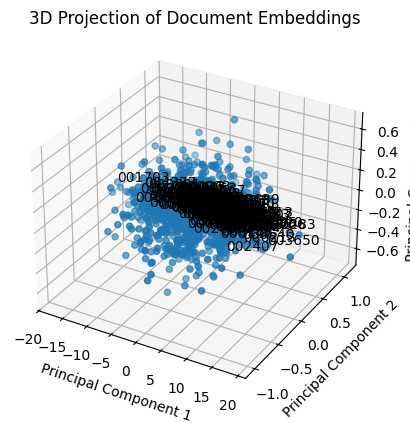

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
import json

embeddings_file = '/home/adi/Dev/CaseGNN/Graph_generation/embeddings-2/test_casegnn_embedding.pt'  # Path to your embeddings file
document_names_file = '/home/adi/Dev/CaseGNN/Graph_generation/embeddings-2/test_casegnn_embedding_case_name_list.json'  # Path to your document names file

def load_embeddings(embeddings_file, document_names_file):
    embeddings = torch.load(embeddings_file).to('cpu')  # Load PyTorch embeddings
    with open(document_names_file, 'r') as f:
        document_names = json.load(f)
    return embeddings, document_names

# Assuming 'embeddings' is your 1500xN matrix of embeddings and 'document_names' is the list of document names.
embeddings, document_names = load_embeddings(embeddings_file, document_names_file)  

# Perform PCA to reduce dimensions to 3
pca = PCA(n_components=3)
reduced_embeddings = pca.fit_transform(embeddings.T)  # Transpose to have shape N x 1500

# Plot the 3D projection
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], reduced_embeddings[:, 2])

# Annotate points with document names
for i, doc_name in enumerate(document_names):
    ax.text(reduced_embeddings[i, 0], reduced_embeddings[i, 1], reduced_embeddings[i, 2], doc_name)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.title('3D Projection of Document Embeddings')
plt.show()


In [4]:
import torch
import json

embeddings_file = '/home/adi/Dev/CaseGNN/PromptCase/promptcase_embedding/test_fact_issue_cross_embedding.pt'  # Path to your embeddings file
document_names_file = '/home/adi/Dev/CaseGNN/PromptCase/promptcase_embedding/test_fact_issue_cross_embedding_case_list.json'  # Path to your document names file

def load_embeddings(embeddings_file, document_names_file):
    embeddings = torch.load(embeddings_file)  # Load PyTorch embeddings
    with open(document_names_file, 'r') as f:
        document_names = json.load(f)
    return embeddings, document_names

# Assuming 'embeddings' is your 1500xN matrix of embeddings and 'document_names' is the list of document names.
embeddings, document_names = load_embeddings(embeddings_file, document_names_file) 

print(len(embeddings))
print(len(embeddings[0][0][0]))
print(embeddings)

1
768
[[tensor([[-0.6181,  0.0970,  0.3965,  ..., -1.2073,  0.5219,  0.9629],
        [-0.6689,  0.1964,  0.1759,  ..., -1.0929,  0.6387,  1.0609],
        [-0.8494,  0.1435,  0.1742,  ..., -1.1279,  0.5536,  1.1225],
        ...,
        [-0.8133,  0.2553,  0.1274,  ..., -1.0377,  0.6244,  1.0699],
        [-0.7144,  0.3139,  0.3029,  ..., -1.0409,  0.5676,  1.1428],
        [-0.6644,  0.1800,  0.2131,  ..., -1.0447,  0.6280,  0.9205]]), tensor([[-0.6947,  0.3898,  0.4241,  ..., -1.1533,  0.5594,  1.1100],
        [-0.7501,  0.2361,  0.0891,  ..., -1.0043,  0.6387,  0.9812],
        [-0.7515,  0.2916, -0.2145,  ..., -1.0026,  0.4562,  1.0573],
        ...,
        [-0.9744,  0.2283,  0.0690,  ..., -1.0048,  0.6640,  1.0909],
        [-0.7836,  0.0968,  0.2529,  ..., -1.1947,  0.6228,  1.1961],
        [-0.8706,  0.0485,  0.0632,  ..., -0.9259,  0.6138,  1.0661]]), tensor([[-0.6181,  0.0970,  0.3965,  ..., -1.2073,  0.5219,  0.9629],
        [-0.6689,  0.1964,  0.1759,  ..., -1.0929,  

/tmp/ipykernel_8079/3319237599.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  embeddings = torch.load(embeddings_file)  # Load PyTorch embeddings
